In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_pickle(r"D:\DataScience\GUVI\Local\Telangana_govt_Ration_distribution_clustering\master_dataset_cleaned.pkl")

# Trend analysis

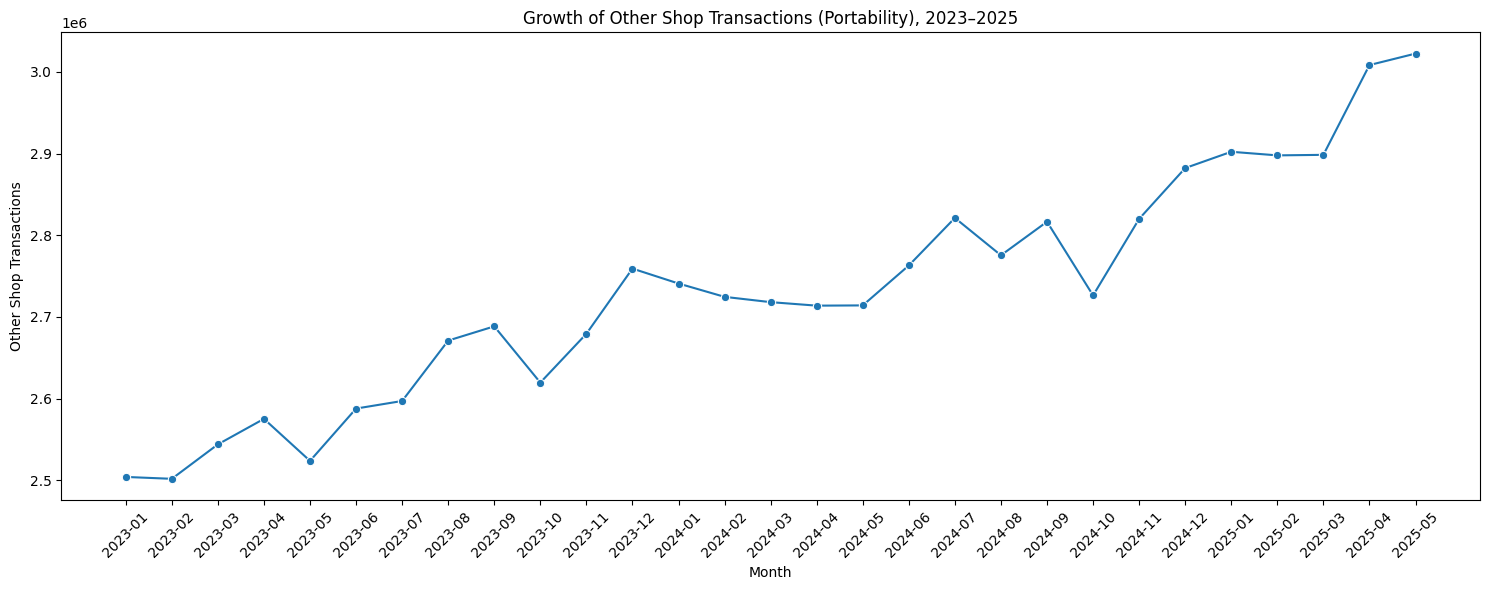

In [3]:
# Create year-month
df["year_month"] = df["date"].dt.to_period("M")

# Monthly portability transactions
portability_trend = (
    df.groupby("year_month")["otherShopTransCnt"]
    .sum()
    .reset_index()
)

portability_trend["year_month"] = portability_trend["year_month"].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(
    data=portability_trend,
    x="year_month",
    y="otherShopTransCnt",
    marker="o"
)

plt.title("Growth of Other Shop Transactions (Portability), 2023–2025")
plt.xlabel("Month")
plt.ylabel("Other Shop Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Overall upward trend: Portability increased from ~2.5M in Jan 2023 to ~3.02M in May 2025 (20%+ growth).
Fluctuations: Some declines occurred, especially around May 2023 and October 2024.
Recent surge: Portability rose sharply from late 2024, reaching its highest level in Apr–May 2025.
Business insight: Increasing portability suggests greater inter-shop beneficiary movement and highlights potential Portability Hubs requiring better stock planning.

# Correlation — totalRcs vs noOfTrans

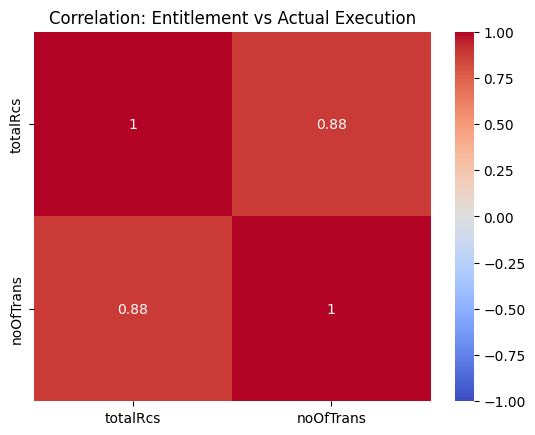

In [4]:
corr = df[["totalRcs", "noOfTrans"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation: Entitlement vs Actual Execution")
plt.show()

Pearson Correlation: 0.8802583842086356


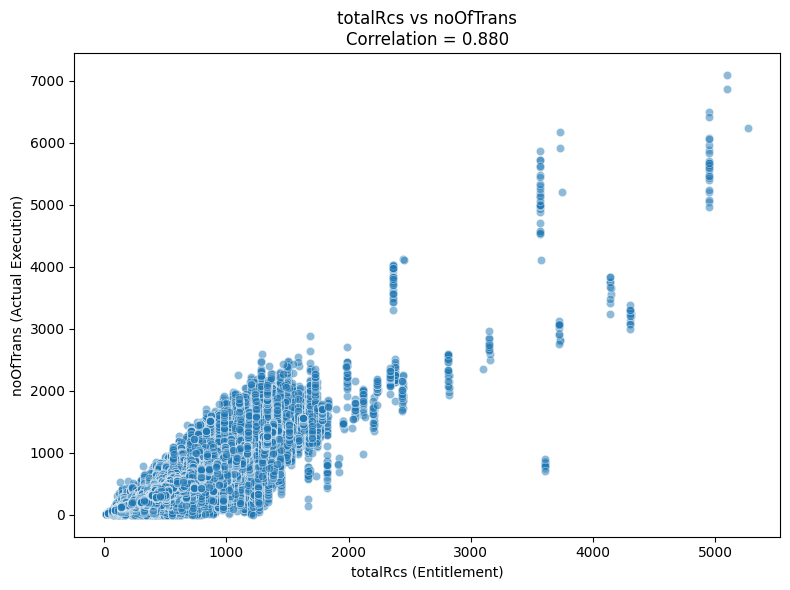

In [5]:
# Correlation value
correlation = df["totalRcs"].corr(df["noOfTrans"])

print("Pearson Correlation:", correlation)

# Scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="totalRcs",
    y="noOfTrans",
    alpha=0.5
)

plt.title(f"totalRcs vs noOfTrans\nCorrelation = {correlation:.3f}")
plt.xlabel("totalRcs (Entitlement)")
plt.ylabel("noOfTrans (Actual Execution)")
plt.tight_layout()
plt.show()

Strong positive correlation (0.88): Shops with more registered ration cards generally perform more transactions.

Positive relationship: Actual execution increases as beneficiary entitlement increases.

Some deviations/outliers: A few shops have unusually low or high transactions compared with their card base.

# Commodity distribution

In [6]:
commodity_cols = [
    "riceAfsc",
    "riceFsc",
    "riceAap",
    "wheat",
    "sugar",
    "rgdal",
    "kerosene",
    "salt"
]
df[commodity_cols]

,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,salt
107144,805.0,4550.0,0.0,0.0,0.0,0.0,0.0,0.0
158855,910.0,4840.0,0.0,0.0,0.0,0.0,0.0,0.0
210522,840.0,4735.0,0.0,0.0,0.0,0.0,0.0,0.0
262228,840.0,5592.0,0.0,0.0,0.0,0.0,0.0,0.0
313919,840.0,5970.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
155092,70.0,4590.0,0.0,0.0,0.0,0.0,0.0,0.0
206751,35.0,4818.0,0.0,0.0,0.0,0.0,0.0,0.0
258457,70.0,4566.0,0.0,0.0,0.0,0.0,0.0,0.0
310148,70.0,5418.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
commodity_cols_1 = [
    "riceAap",
    "wheat",
    "sugar",
    "rgdal",
    "kerosene",
    "salt"
]
zero_percentage = (
    df[commodity_cols_1].eq(0).mean() * 100
).sort_values(ascending=False)

print(zero_percentage)

rgdal       100.000000
salt         99.911510
kerosene     99.653249
riceAap      92.696008
wheat        92.367876
sugar        87.612664
dtype: float64


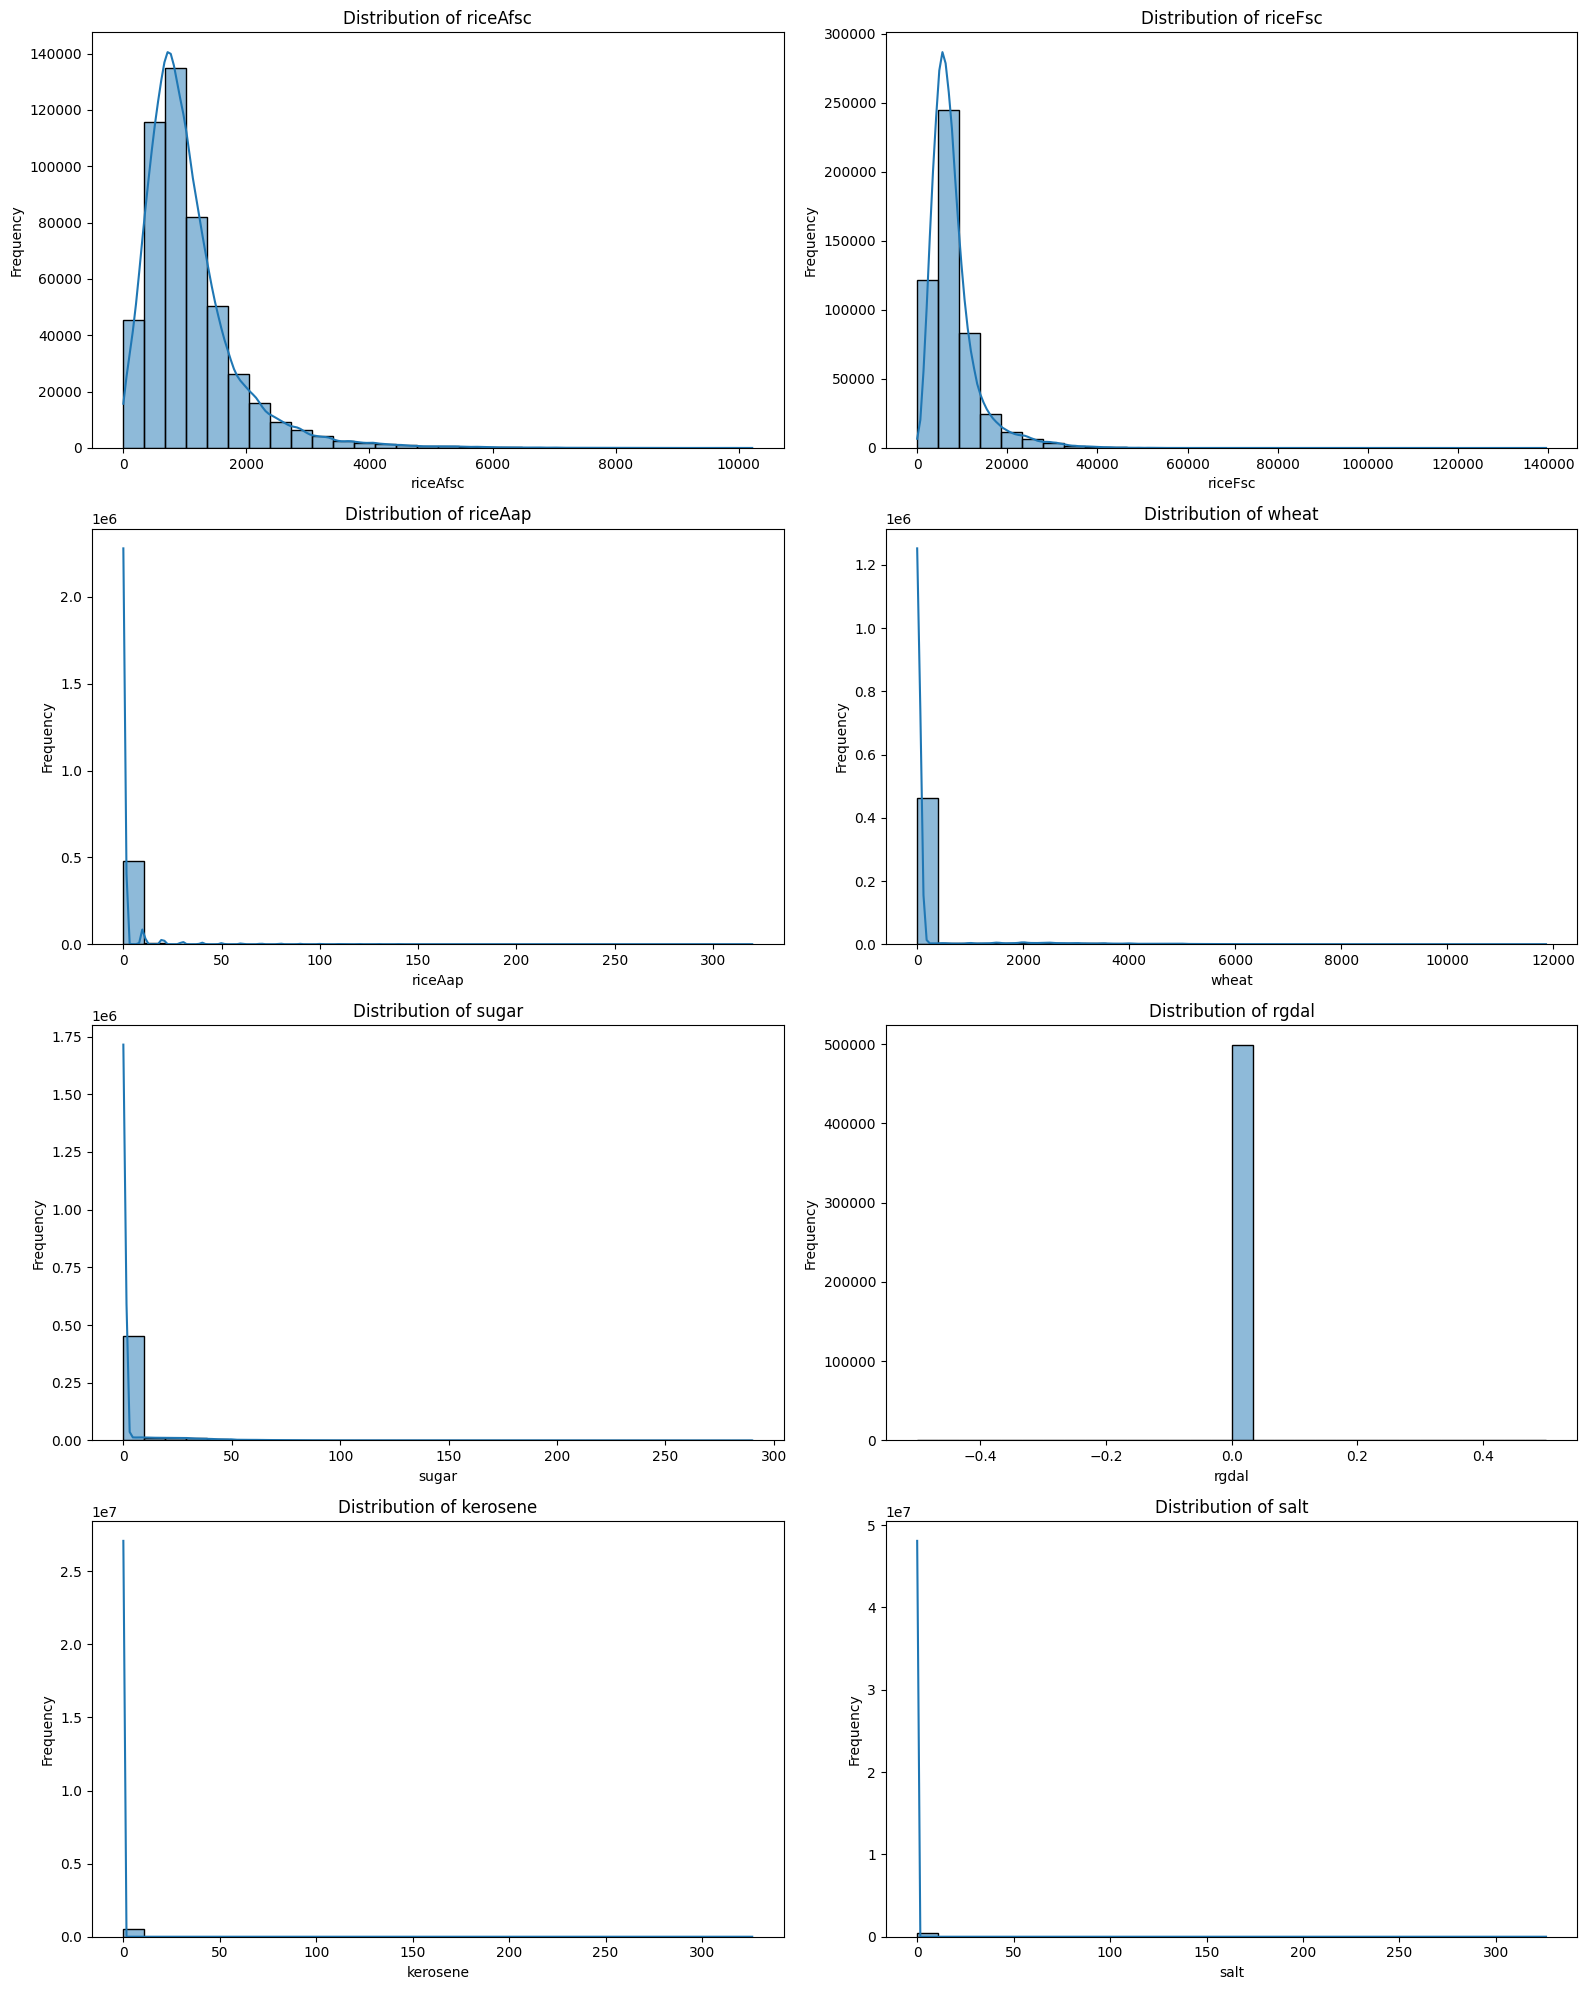

In [8]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 20)
)

axes = axes.flatten()
for ax, col in zip(axes, commodity_cols):

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

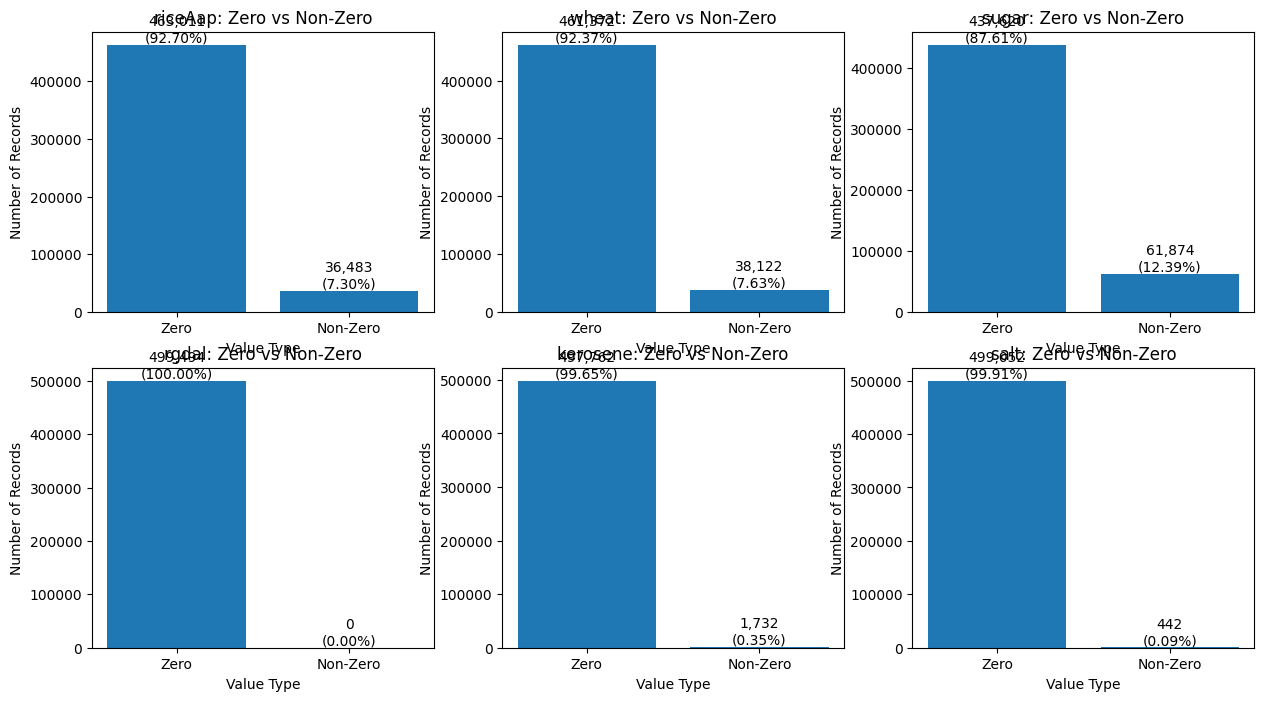

In [9]:
n = len(commodity_cols_1)

fig, axes = plt.subplots(
    nrows=(n + 2) // 3,
    ncols=3,
    figsize=(15, 4 * ((n + 2) // 3))
)

axes = axes.flatten()

for ax, col in zip(axes, commodity_cols_1):

    zero_count = (df[col] == 0).sum()
    nonzero_count = (df[col] > 0).sum()

    total = zero_count + nonzero_count

    zero_pct = zero_count / total * 100
    nonzero_pct = nonzero_count / total * 100

    values = [zero_count, nonzero_count]

    bars = ax.bar(
        ['Zero', 'Non-Zero'],
        values
    )

    ax.set_title(f'{col}: Zero vs Non-Zero')
    ax.set_xlabel('Value Type')
    ax.set_ylabel('Number of Records')

    # Add count and percentage
    for bar, count, pct in zip(
        bars,
        values,
        [zero_pct, nonzero_pct]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{count:,}\n({pct:.2f}%)',
            ha='center',
            va='bottom'
        )


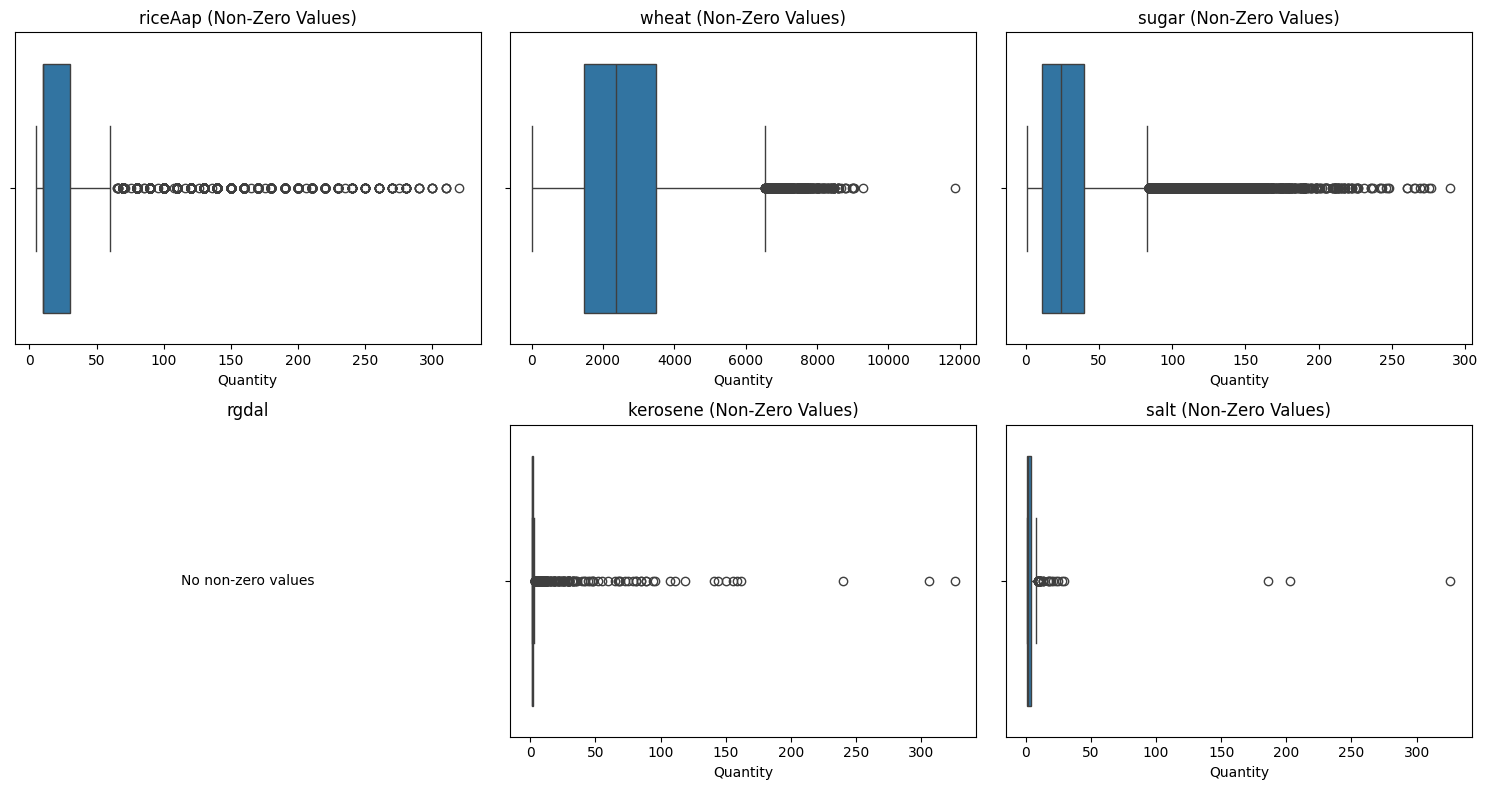

In [10]:
import math
n = len(commodity_cols_1)

# Arrange subplots
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))

# Make axes 1D
axes = axes.flatten()

for ax, col in zip(axes, commodity_cols_1):

    values = df.loc[df[col] > 0, col]

    if values.empty:
        ax.text(0.5, 0.5, "No non-zero values",
                ha="center", va="center")
        ax.set_title(col)
        ax.set_axis_off()
        continue

    sns.boxplot(x=values, ax=ax)

    ax.set_title(f'{col} (Non-Zero Values)')
    ax.set_xlabel('Quantity')

# Hide unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

FSC transactions dominate, with much higher transaction counts than AFSC and AAP.

AFSC transactions are also significant, while AAP transactions are mostly zero.

Other commodities are measured in physical quantities (kg, litres, etc.), so their values should not be directly compared with transaction counts.

Wheat, sugar, kerosene, salt, etc. appear mostly zero in these records, indicating limited distribution of these commodities compared with rice transactions.

Key insight: Shop activity is primarily driven by FSC and AFSC rice transactions, while other commodities represent the quantity distributed, not the number of transactions

# seasonality in transaction

In [11]:
monthly_transactions = (
    df.groupby(["year", "month"])["noOfTrans"]
      .sum()
      .reset_index()
)

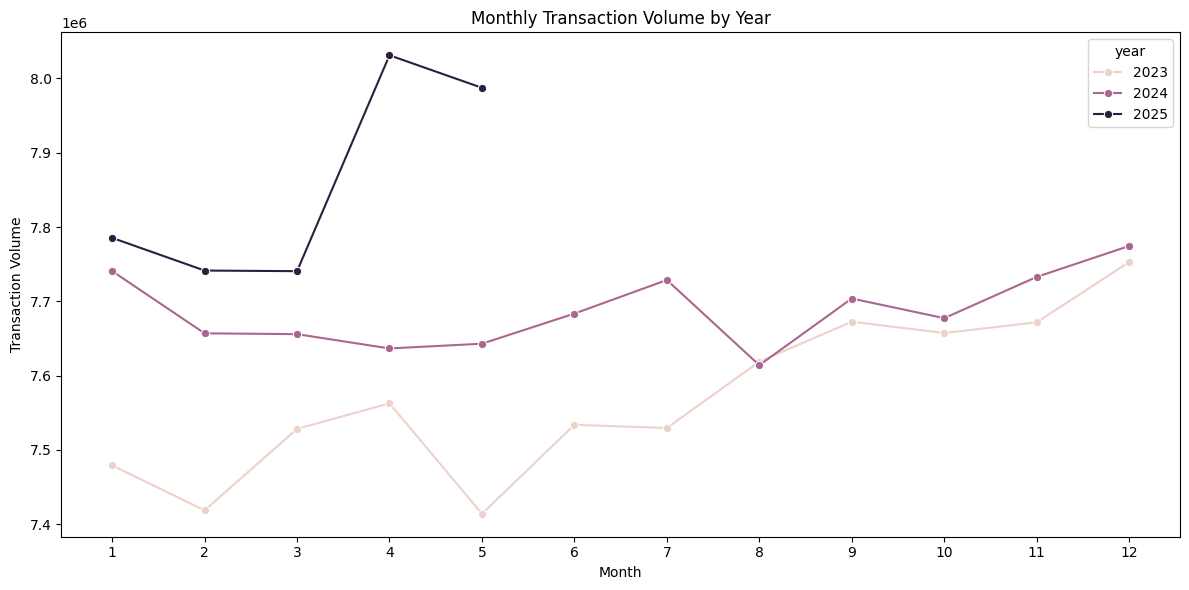

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_transactions,
    x="month",
    y="noOfTrans",
    hue="year",
    marker="o"
)

plt.title("Monthly Transaction Volume by Year")
plt.xlabel("Month")
plt.ylabel("Transaction Volume")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Consistent Year-over-Year Growth: Transaction volume shows clear upward trajectory from 2023 to 2025 across all plotted months, with 2025 outperforming previous years significantly.

2025 Volume Spike: Monthly volume peaks in Month 4 (April) of 2025, topping 8.03 million, compared to around 7.56M in 2023 and 7.64M in 2024 for the same month.

Late-Year Surge Pattern: In both full years (2023 and 2024), transaction volume trends upward in the final quarter (Months 9–12), reaching annual highs in Month 12 (~7.75M in 2024).

Mid-Year Dips: Noticeable declines occur around Month 5 in 2023 and Month 8 in 2024 before volume recovers.